In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *


In [2]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'jpmf_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    
    results_by_label = {
        # "PC": results_pc,
        # "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        # "EA-HC": results_ea_hc,
        # "EA-Base": results_ea_ues,
        # "EA-IES": results_ea_ies,
        # "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        # "NOTEARS": results_notears,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


load_results(subset)
long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df[""]]



In [3]:
long_df.columns

Index(['n_nodes', 'n_pairs', 'SHD [Skeleton]', 'Type Confusions [Adjacency]',
       'n_true [Adjacency]', 'n_pred [Adjacency]', 'TP [Adjacency]',
       'FP [Adjacency]', 'FN [Adjacency]', 'Precision [Skeleton]',
       'Recall [Skeleton]', 'F1 [Skeleton]', 'Total (Colliders)',
       'TP (Found Colliders)', 'FP (Extra Colliders)',
       'FN (Missing Colliders )', 'TP (Synergy)', 'FN (Synergy)', 'Total (SC)',
       'Precision [Collider]', 'Recall [Collider]', 'F1 [Collider]',
       'Precision [Synergy]', 'Recall [Synergy]', 'F1 [Synergy]', 'Total (PW)',
       'TP (Pairwise)', 'FN (Pairwise)', 'Precision [Pairwise]',
       'Recall [Pairwise]', 'F1 [Pairwise]', 'i', 'family', 'target_mi',
       'pair_probs', 'syn_cutoff', 'num_vars', 'TrueBIC', 'BIC', 'WallTime_s',
       'CPUTime_s', 'RSS_before_MB', 'RSS_after_MB', 'RSS_delta_MB',
       'PeakRSS_MB', 'PyAllocPeak_MB', 'Algorithm', 'run_id'],
      dtype='object')

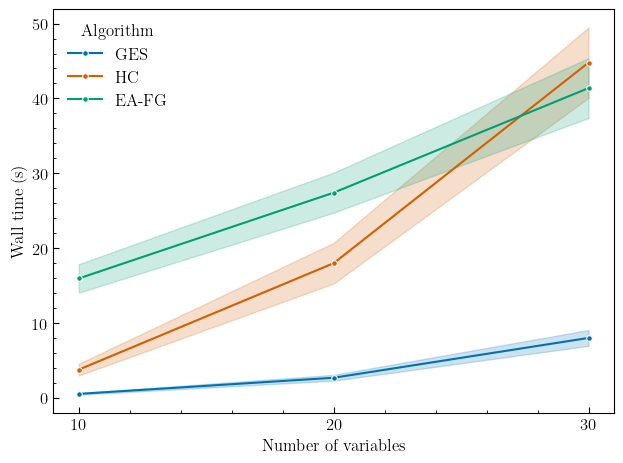

In [4]:
sns.lineplot(
    data=long_df,
    x="num_vars",
    y="WallTime_s",
    hue="Algorithm",
    marker="o",
    errorbar="sd"
)

plt.xticks([10, 20, 30])
plt.xlabel("Number of variables")
plt.ylabel("Wall time (s)")
# plt.title("Runtime by algorithm and number of variables")
plt.tight_layout()
plt.savefig("Figures/WallTime_s.png", dpi=800, bbox_inches="tight")
plt.show()


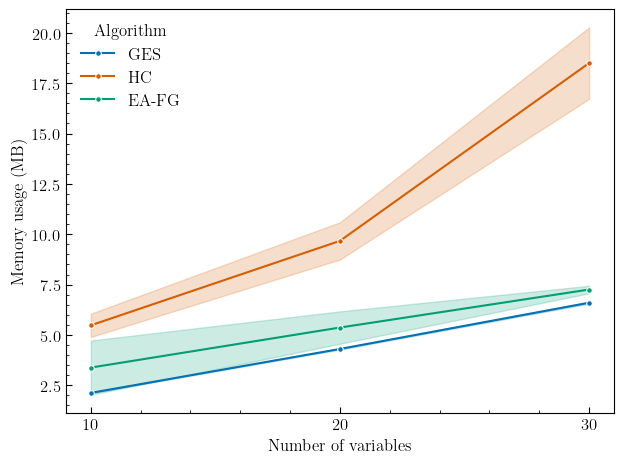

In [5]:
sns.lineplot(
    data=long_df,
    x="num_vars",
    y="PyAllocPeak_MB",
    hue="Algorithm",
    marker="o",
    errorbar="sd"
)

plt.xticks([10, 20, 30])
plt.xlabel("Number of variables")
plt.ylabel("Memory usage (MB)")
# plt.title("Runtime by algorithm and number of variables")
plt.tight_layout()
plt.savefig("Figures/PyAllocPeak_MB.png", dpi=800, bbox_inches="tight")
plt.show()
